# Assignment 1 - Data cleaning 

In [ ]:
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
#from pypots.imputation import BRITS
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'pandas'

In [71]:
# import data 
raw_df = pd.read_csv("dataset_mood_smartphone.csv", low_memory=False)
raw_df.columns = ['index', 'id', 'time', 'variable', 'value']

In [72]:
# get variables 
vars = raw_df['variable'].unique()
print(f"All variables: {vars}")
print(f"Total: {len(vars)} variables\n")

# summary stats per variable
for var in sorted(vars):
    subset = raw_df[raw_df['variable'] == var]['value']
    print(f"--- {var} ---")
    print(f"NaN count: {subset.isna().sum()}")
    print(subset.describe())
    print()

nan_rows = raw_df[raw_df["value"].isna()].sort_values(['id','time']).copy()
print("\nNaN rows:")
print(nan_rows.to_string())


All variables: ['mood' 'circumplex.arousal' 'circumplex.valence' 'activity' 'screen'
 'call' 'sms' 'appCat.builtin' 'appCat.communication'
 'appCat.entertainment' 'appCat.finance' 'appCat.game' 'appCat.office'
 'appCat.other' 'appCat.social' 'appCat.travel' 'appCat.unknown'
 'appCat.utilities' 'appCat.weather']
Total: 19 variables

--- activity ---
NaN count: 0
count    22965.000000
mean         0.115958
std          0.186946
min          0.000000
25%          0.000000
50%          0.021739
75%          0.158333
max          1.000000
Name: value, dtype: float64

--- appCat.builtin ---
NaN count: 0
count    91288.000000
mean        18.538262
std        415.989243
min     -82798.871000
25%          2.020000
50%          4.038000
75%          9.922000
max      33960.246000
Name: value, dtype: float64

--- appCat.communication ---
NaN count: 0
count    74276.000000
mean        43.343792
std        128.912750
min          0.006000
25%          5.218000
50%         16.225500
75%         45.4

### incorrect values detection 

In [73]:
# predefined intervals 
fixed_bounds = {
    'mood':                  (1,10),
    'circumplex.arousal':    (-2,2),
    'circumplex.valence':    (-2,2),
    'activity':              (0,1),
    'call':                  (1,1), 
    'sms':                   (1,1),
    'screen':                (0, None),
    'appCat.builtin':        (0, None),
    'appCat.communication':  (0, None),
    'appCat.entertainment':  (0, None),
    'appCat.finance':        (0, None),
    'appCat.game':           (0, None),
    'appCat.office':         (0, None),
    'appCat.other':          (0, None),
    'appCat.social':         (0, None),
    'appCat.travel':         (0, None),
    'appCat.unknown':        (0, None),
    'appCat.utilities':      (0, None),
    'appCat.weather':        (0, None),
}

incorrect_records = []
for var, (low, high) in fixed_bounds.items():
    subset = raw_df[raw_df['variable'] == var]
    if high is not None:
        mask = (subset['value'] < low) | (subset['value'] > high)
    else: 
        mask = (subset['value'] < low)
    
    mark = subset[mask].copy()
    mark['reason'] = 'incorrect_value'
    mark['original_index'] = mark.index
    incorrect_records.append(mark)

incorrect_df = pd.concat(incorrect_records, ignore_index = True)
print(f"Total incorrect values found: {len(incorrect_df)}")
print(incorrect_df['variable'].value_counts())
print(incorrect_df)

Total incorrect values found: 4
variable
appCat.builtin          3
appCat.entertainment    1
Name: count, dtype: int64
    index       id                     time              variable      value  \
0  151512  AS14.02  2014-03-16 15:46:43.769        appCat.builtin    -44.689   
1  622771  AS14.07  2014-04-30 14:18:06.200        appCat.builtin -82798.871   
2  754571  AS14.12  2014-04-02 16:42:16.523        appCat.builtin     -1.218   
3  484694  AS14.02  2014-03-26 21:18:45.144  appCat.entertainment     -0.011   

            reason  original_index  
0  incorrect_value          150040  
1  incorrect_value          159972  
2  incorrect_value          162154  
3  incorrect_value          309805  


### extreme values detection 

In [74]:
# applied to duration variables that have no fixed upper bound
dur_vars = ['screen'] + [v for v in fixed_bounds if v.startswith('appCat')]

# remove incorrect values 
# rem_inc_df = raw_df[~raw_df.index.isin(incorrect_df.index)].copy()

# check the time intervals
raw_df['time'] = pd.to_datetime(raw_df['time'])

sorted_df = raw_df.sort_values(['id', 'variable', 'time'])

sorted_df['time_gap_sec'] = (
    sorted_df.groupby(['id', 'variable'])['time']
    .diff()
    .dt.total_seconds()
)

# for first row of each group has NaN - use median gap of the variable as fallback
med_gaps = sorted_df.groupby('variable')['time_gap_sec'].median()
sorted_df['time_gap_sec'] = sorted_df.apply(
    lambda row: med_gaps[row['variable']]
    if pd.isna(row['time_gap_sec'])
    else row['time_gap_sec'],
    axis = 1 
)

# Mark duration outliers based on time interval violation only 
interval_violations = []

for var in dur_vars:
    subset = sorted_df[sorted_df['variable'] == var]
    mark = subset[subset['value'] > subset['time_gap_sec']].copy()
    mark['reason'] = 'exceeds_time_interval'
    mark['original_index'] = mark.index  # store original index explicitly
    interval_violations.append(mark)

# ignore_index=True is fine now since we stored original indexes separately
interval_violation_df = pd.concat(interval_violations, ignore_index=True)
print(f"Duration rows exceeding time interval: {len(interval_violation_df)}")
print(interval_violation_df['variable'].value_counts())

Duration rows exceeding time interval: 45995
variable
appCat.communication    13765
screen                  12823
appCat.builtin          11592
appCat.social            3277
appCat.entertainment     2767
appCat.office             369
appCat.travel             351
appCat.finance            306
appCat.other              301
appCat.utilities          176
appCat.game               135
appCat.unknown            123
appCat.weather             10
Name: count, dtype: int64


* Because of different time intervals, IQR / box plots fail. 
* Replace IQR with time interval check 

### imputing missing values

In [75]:
clean_df = clean_df.copy()
clean_df['time'] = pd.to_datetime(clean_df['time'])

# define target and feature sets
target_vars = ['circumplex.arousal', 'circumplex.valence']
target_long = clean_df[clean_df["variable"].isin(target_vars)].copy()
mood_long = clean_df[clean_df["variable"] == 'mood'].copy()
feature_long = clean_df[~clean_df["variable"].isin(target_vars + ['mood'])].copy()

target_wide = (
    target_long
    .pivot_table(index=["id", "time"], columns="variable", values="value", aggfunc="mean")
    .reset_index()
    .sort_values(["id", "time"])
    .copy()
)

print(target_wide.shape)
print(target_wide.head())

(5591, 4)
variable       id                time  circumplex.arousal  circumplex.valence
0         AS14.01 2014-02-26 13:00:00                -1.0                 0.0
1         AS14.01 2014-02-26 15:00:00                -1.0                 1.0
2         AS14.01 2014-02-26 18:00:00                 0.0                 1.0
3         AS14.01 2014-02-26 21:00:00                 1.0                 1.0
4         AS14.01 2014-02-27 09:00:00                -2.0                 0.0


In [76]:
agg_rule_map = {
    "activity": "mean",
    "screen": "sum",
    "call": "sum",
    "sms": "sum",
    
    "appCat.builtin": "sum",
    "appCat.communication": "sum",
    "appCat.entertainment": "sum",
    "appCat.finance": "sum",
    "appCat.game": "sum",
    "appCat.office": "sum",
    "appCat.other": "sum",
    "appCat.social": "sum",
    "appCat.travel": "sum",
    "appCat.unknown": "sum",
    "appCat.utilities": "sum",
    "appCat.weather": "sum",
}

In [77]:
def align_features_to_target_times_window_rules(
    feature_long,
    target_wide,
    agg_rule_map,
    id_col="id",
    time_col="time",
    window="24h",
    default_rule="mean"
):
    feature_long = feature_long.copy()
    target_wide = target_wide.copy()

    feature_long[time_col] = pd.to_datetime(feature_long[time_col])
    target_wide[time_col] = pd.to_datetime(target_wide[time_col])

    feature_vars = sorted(feature_long["variable"].dropna().unique())
    out = []

    for sid, target_g in target_wide.groupby(id_col, sort=False):
        target_g = target_g.sort_values(time_col).copy()
        feat_g = feature_long[feature_long[id_col] == sid].sort_values(time_col).copy()

        rows = []

        for _, row in target_g.iterrows():
            t = row[time_col]
            start = t - pd.Timedelta(window)

            sub = feat_g[(feat_g[time_col] > start) & (feat_g[time_col] <= t)]

            merged = row.to_dict()

            if sub.empty:
                for v in feature_vars:
                    merged[v] = np.nan
            else:
                for v in feature_vars:
                    sub_v = sub.loc[sub["variable"] == v, "value"]

                    if sub_v.empty:
                        merged[v] = np.nan
                    else:
                        rule = agg_rule_map.get(v, default_rule)

                        if rule == "mean":
                            merged[v] = sub_v.mean()
                        elif rule == "sum":
                            merged[v] = sub_v.sum()
                        elif rule == "max":
                            merged[v] = sub_v.max()
                        elif rule == "last":
                            merged[v] = sub_v.iloc[-1]
                        else:
                            raise ValueError(f"Unknown aggregation rule '{rule}' for variable '{v}'")

            rows.append(merged)

        out.append(pd.DataFrame(rows))

    return pd.concat(out, ignore_index=True)

In [78]:
df_aligned = align_features_to_target_times_window_rules(
    feature_long=feature_long,
    target_wide=target_wide,
    agg_rule_map=agg_rule_map,
    window="24h"
)

mood_wide = (
    mood_long
    .pivot_table(index=["id", "time"], values="value", aggfunc="mean")
    .reset_index()
    .rename(columns={"value": "mood"})
)

df_aligned = df_aligned.merge(mood_wide, on=["id", "time"], how="left")

print(df_aligned.shape)
print(df_aligned.head(30))

(5591, 21)
         id                time  circumplex.arousal  circumplex.valence  \
0   AS14.01 2014-02-26 13:00:00                -1.0                 0.0   
1   AS14.01 2014-02-26 15:00:00                -1.0                 1.0   
2   AS14.01 2014-02-26 18:00:00                 0.0                 1.0   
3   AS14.01 2014-02-26 21:00:00                 1.0                 1.0   
4   AS14.01 2014-02-27 09:00:00                -2.0                 0.0   
5   AS14.01 2014-02-27 12:00:00                 1.0                 0.0   
6   AS14.01 2014-02-27 15:00:00                 1.0                 1.0   
7   AS14.01 2014-03-21 09:00:00                -1.0                 0.0   
8   AS14.01 2014-03-21 11:00:00                 0.0                 0.0   
9   AS14.01 2014-03-21 15:00:00                 1.0                 1.0   
10  AS14.01 2014-03-21 19:00:00                 0.0                 0.0   
11  AS14.01 2014-03-21 21:00:00                 1.0                 0.0   
12  AS14.01 20

In [79]:
feature_vars = [c for c in df_aligned.columns if c not in ["id", "time"] + target_vars]

for col in feature_vars:
    df_aligned[f"{col}_observed_24h"] = df_aligned[col].notna().astype(int)

print(df_aligned.head())

        id                time  circumplex.arousal  circumplex.valence  \
0  AS14.01 2014-02-26 13:00:00                -1.0                 0.0   
1  AS14.01 2014-02-26 15:00:00                -1.0                 1.0   
2  AS14.01 2014-02-26 18:00:00                 0.0                 1.0   
3  AS14.01 2014-02-26 21:00:00                 1.0                 1.0   
4  AS14.01 2014-02-27 09:00:00                -2.0                 0.0   

   activity  appCat.builtin  appCat.communication  appCat.entertainment  \
0       NaN             NaN                   NaN                   NaN   
1       NaN             NaN                   NaN                   NaN   
2       NaN             NaN                   NaN                   NaN   
3       NaN             NaN                   NaN                   NaN   
4       NaN             NaN                   NaN                   NaN   

   appCat.finance  appCat.game  ...  appCat.other_observed_24h  \
0             NaN          NaN  ...   

In [80]:
# add cyclical features 
df_aligned["hour"] = df_aligned["time"].dt.hour
df_aligned["dayofweek"] = df_aligned["time"].dt.dayofweek

df_aligned["Hour_Sin"] = np.sin(2 * np.pi * df_aligned["hour"] / 24)
df_aligned["Hour_Cos"] = np.cos(2 * np.pi * df_aligned["hour"] / 24)
df_aligned["Day_Sin"] = np.sin(2 * np.pi * df_aligned["dayofweek"] / 7)
df_aligned["Day_Cos"] = np.cos(2 * np.pi * df_aligned["dayofweek"] / 7)

In [81]:
# split dataset
sub = df_aligned['id'].drop_duplicates().tolist()

train_ids, temp_ids = train_test_split(sub, test_size = 0.30, random_state = 42)
val_ids, test_ids = train_test_split(temp_ids, test_size = 0.50, random_state = 42)

train_df = df_aligned[df_aligned['id'].isin(train_ids)].copy()
val_df = df_aligned[df_aligned['id'].isin(val_ids)].copy()
test_df = df_aligned[df_aligned['id'].isin(test_ids)].copy()

print("Train subjects:", len(train_ids))
print("Val subjects:", len(val_ids))
print("Test subjects:", len(test_ids))
print(train_df.shape, val_df.shape, test_df.shape)

Train subjects: 18
Val subjects: 4
Test subjects: 5
(3672, 44) (779, 44) (1140, 44)


#### Approach 1: linear interpolation

In [82]:
def interpolate_target_within_subject(df, target_vars, id_col = 'id', time_col = 'time'):
    out=[]
    for sid, g in df.groupby(id_col, sort = False):
        g = g.sort_values(time_col).copy()
        g = g.set_index(time_col)

        for var in target_vars:
            g[f"{var}_was_observed"] = g[var].notna().astype(int)
            g[var] = g[var].interpolate(method = 'time', limit_direction='both')
            g[var] = g[var].ffill().bfill()
        
        g = g.reset_index()
        out.append(g)

    return pd.concat(out, ignore_index = True)

In [92]:
train_imp = interpolate_target_within_subject(train_df, target_vars)
val_imp   = interpolate_target_within_subject(val_df, target_vars)
test_imp  = interpolate_target_within_subject(test_df, target_vars)

train_imp.to_csv("train_imp.csv", index=False)
val_imp.to_csv("val_imp.csv", index=False)
test_imp.to_csv("test_imp.csv", index=False)

print(train_imp[target_vars].isna().sum())
print(val_imp[target_vars].isna().sum())
print(test_imp[target_vars].isna().sum())

circumplex.arousal    0
circumplex.valence    0
dtype: int64
circumplex.arousal    0
circumplex.valence    0
dtype: int64
circumplex.arousal    0
circumplex.valence    0
dtype: int64


#### Approach 2:  BRITS imputation

In [84]:
id_col = 'id'
time_col = 'time'

exclude_cols = {
    id_col, time_col, 
    'hour', 'dayofweek', 'Hour_Sin', 'Hour_Cos', 'Day_Sin', 'Day_Cos'
}

exclude_cols.update([c for c in train_df.columns if c.endswith('_was_observed')])
exclude_cols.update([c for c in train_df.columns if c.endswith('_observed_24h')])

value_cols = [
    c for c in train_df.columns
    if c not in exclude_cols and pd.api.types.is_any_real_numeric_dtype(train_df[c])
]

print("Number of BRITS variables:", len(value_cols))
print(value_cols[:20])

Number of BRITS variables: 19
['circumplex.arousal', 'circumplex.valence', 'activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'screen', 'sms', 'mood']


In [85]:
def prepare_split(df, id_col = 'id', time_col = 'time'):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)
    return df

train_df = prepare_split(train_df, id_col, time_col)
val_df   = prepare_split(val_df, id_col, time_col)
test_df  = prepare_split(test_df, id_col, time_col)

In [86]:
# BRITS usually behaves better if variables are on similar scales.
def fit_train_scaler(train_df, value_cols):
    means = train_df[value_cols].mean(skipna=True)
    stds = train_df[value_cols].std(skipna=True).replace(0, 1.0)
    return means, stds

def apply_scaler(df, value_cols, means, stds):
    df = df.copy()
    df[value_cols] = (df[value_cols] - means) / stds
    return df

train_means, train_stds = fit_train_scaler(train_df, value_cols)

train_scaled = apply_scaler(train_df, value_cols, train_means, train_stds)
val_scaled   = apply_scaler(val_df, value_cols, train_means, train_stds)
test_scaled  = apply_scaler(test_df, value_cols, train_means, train_stds)

In [87]:
def df_to_padded_tensor(df, value_cols, id_col="id", time_col="time", max_len=None):
    groups = []
    subject_ids = []
    lengths = []

    grouped = list(df.groupby(id_col, sort=False))

    if max_len is None:
        max_len = max(len(g) for _, g in grouped)

    for sid, g in grouped:
        g = g.sort_values(time_col)
        X = g[value_cols].to_numpy(dtype=float)

        lengths.append(len(g))
        subject_ids.append(sid)

        if len(g) < max_len:
            pad = np.full((max_len - len(g), len(value_cols)), np.nan, dtype=float)
            X = np.vstack([X, pad])
        elif len(g) > max_len:
            raise ValueError(f"Subject {sid} has length {len(g)} > max_len {max_len}")

        groups.append(X)

    X = np.stack(groups, axis=0)
    return X, subject_ids, lengths

In [88]:
train_grouped = list(train_scaled.groupby(id_col, sort=False))
val_grouped   = list(val_scaled.groupby(id_col, sort=False))
test_grouped  = list(test_scaled.groupby(id_col, sort=False))

global_max_len = max(
    max(len(g) for _, g in train_grouped),
    max(len(g) for _, g in val_grouped),
    max(len(g) for _, g in test_grouped),
)

print("global_max_len =", global_max_len)

global_max_len = 328


In [89]:
X_train, train_subject_ids, train_lengths = df_to_padded_tensor(
    train_scaled, value_cols, id_col, time_col, max_len=global_max_len
)

X_val, val_subject_ids, val_lengths = df_to_padded_tensor(
    val_scaled, value_cols, id_col, time_col, max_len=global_max_len
)

X_test, test_subject_ids, test_lengths = df_to_padded_tensor(
    test_scaled, value_cols, id_col, time_col, max_len=global_max_len
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (18, 328, 19)
X_val:   (4, 328, 19)
X_test:  (5, 328, 19)


In [90]:
# fit BRITS on training only 
brits = BRITS(
    n_steps = X_train.shape[1],
    n_features = X_train.shape[2],
    rnn_hidden_size = 64,
    batch_size = 16, 
    epochs = 50,
    patience = 5,
    device = 'cpu',
)

brits.fit({"X": X_train})

NameError: name 'BRITS' is not defined

In [ ]:
# impute all splits using the trained model
X_train_brits = brits.impute({"X": X_train})
X_val_brits   = brits.impute({"X": X_val})
X_test_brits  = brits.impute({"X": X_test})

In [ ]:
def padded_tensor_to_df(X_imp, original_df, subject_ids, lengths, value_cols,
                        id_col="id", time_col="time"):
    out = []

    for i, (sid, L) in enumerate(zip(subject_ids, lengths)):
        g = original_df[original_df[id_col] == sid].sort_values(time_col).copy()
        g[value_cols] = X_imp[i, :L, :]
        out.append(g)

    return pd.concat(out, axis=0, ignore_index=True)

In [ ]:
train_brits = padded_tensor_to_df(
    X_train_brits, train_df, train_subject_ids, train_lengths, value_cols
)

val_brits = padded_tensor_to_df(
    X_val_brits, val_df, val_subject_ids, val_lengths, value_cols
)

test_brits = padded_tensor_to_df(
    X_test_brits, test_df, test_subject_ids, test_lengths, value_cols
)

In [ ]:
def inverse_scaler(df, value_cols, means, stds):
    df = df.copy()
    df[value_cols] = df[value_cols] * stds + means
    return df

train_brits_df = inverse_scaler(train_brits, value_cols, train_means, train_stds)
val_brits_df   = inverse_scaler(val_brits, value_cols, train_means, train_stds)
test_brits_df  = inverse_scaler(test_brits, value_cols, train_means, train_stds)

#### Distributional Check

In [ ]:
def distribution_check_two_imputers(original_df, interp_df, brits_df, target_vars,
                                    id_col="id", time_col="time"):
    rows = []

    for var in target_vars:
        observed_mask = original_df[var].notna()
        missing_mask = original_df[var].isna()

        observed_vals = original_df.loc[observed_mask, var].dropna()
        interp_imputed_vals = interp_df.loc[missing_mask, var].dropna()
        brits_imputed_vals = brits_df.loc[missing_mask, var].dropna()

        def summarize(x, label):
            if len(x) == 0:
                return {
                    "variable": var,
                    "group": label,
                    "n": 0,
                    "mean": np.nan,
                    "std": np.nan,
                    "min": np.nan,
                    "q25": np.nan,
                    "median": np.nan,
                    "q75": np.nan,
                    "max": np.nan
                }
            return {
                "variable": var,
                "group": label,
                "n": len(x),
                "mean": x.mean(),
                "std": x.std(),
                "min": x.min(),
                "q25": x.quantile(0.25),
                "median": x.median(),
                "q75": x.quantile(0.75),
                "max": x.max()
            }

        rows.append(summarize(observed_vals, "observed_original"))
        rows.append(summarize(interp_imputed_vals, "imputed_linear"))
        rows.append(summarize(brits_imputed_vals, "imputed_brits"))

    return pd.DataFrame(rows)

In [ ]:
dist_train = distribution_check_two_imputers(train_df, train_imp, train_brits, target_vars)
dist_val   = distribution_check_two_imputers(val_df, val_imp, val_brits, target_vars)
dist_test  = distribution_check_two_imputers(test_df, test_imp, test_brits, target_vars)

print(dist_train)
print(dist_val)
print(dist_test)

             variable              group     n      mean       std       min  \
0  circumplex.arousal  observed_original  3668 -0.165622  1.040381 -2.000000   
1  circumplex.arousal     imputed_linear     4 -0.097619  0.819836 -1.000000   
2  circumplex.arousal      imputed_brits     4  0.017510  0.074389 -0.050644   
3  circumplex.valence  observed_original  3659  0.636513  0.700808 -2.000000   
4  circumplex.valence     imputed_linear    13  0.461881  0.453191 -0.200000   
5  circumplex.valence      imputed_brits    13  0.000031  0.058217 -0.113662   

        q25    median       q75       max  
0 -1.000000  0.000000  1.000000  2.000000  
1 -0.678571 -0.052381  0.528571  0.714286  
2 -0.025380 -0.000295  0.042595  0.121274  
3  0.000000  1.000000  1.000000  2.000000  
4  0.000000  0.375000  1.000000  1.035088  
5 -0.036601  0.009732  0.046240  0.089409  
             variable              group    n      mean       std       min  \
0  circumplex.arousal  observed_original  777 -0.245

#### Visual Inspection

In [ ]:
def plot_subject_imputation_compare(original_df, interp_df, brits_df, subject_id, target_vars,
                                    id_col="id", time_col="time"):
    orig = original_df[original_df[id_col] == subject_id].sort_values(time_col).copy()
    lin  = interp_df[interp_df[id_col] == subject_id].sort_values(time_col).copy()
    bri  = brits_df[brits_df[id_col] == subject_id].sort_values(time_col).copy()

    for var in target_vars:
        plt.figure(figsize=(10, 4))
        plt.scatter(orig[time_col], orig[var], label="Observed original", s=20)
        plt.plot(lin[time_col], lin[var], label="Linear interpolation", linewidth=2)
        plt.plot(bri[time_col], bri[var], label="BRITS", linewidth=2)
        plt.title(f"Subject {subject_id} - {var}")
        plt.xlabel("time")
        plt.ylabel(var)
        plt.legend()
        plt.tight_layout()
        plt.show()

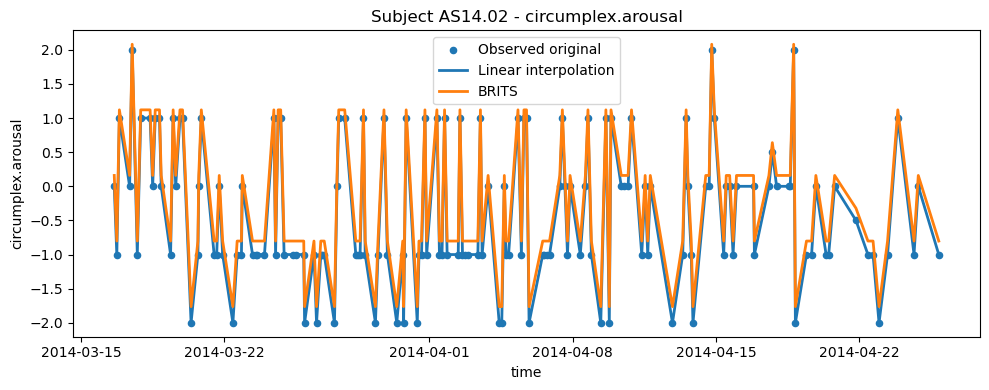

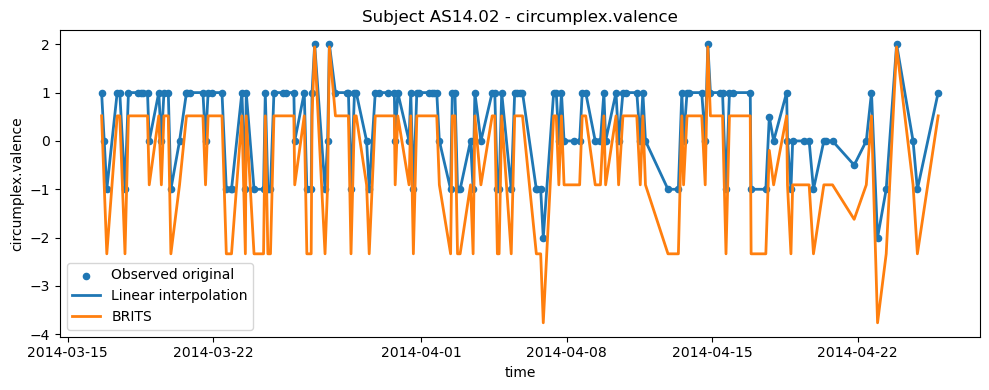

In [ ]:
example_subject = train_df["id"].iloc[0]
plot_subject_imputation_compare(train_df, train_imp, train_brits, example_subject, target_vars)

#### Gap-length Sensitivity

In [ ]:
def add_gap_length_info(original_df, target_vars, id_col="id", time_col="time"):
    out = []

    for sid, g in original_df.groupby(id_col, sort=False):
        g = g.sort_values(time_col).copy()

        for var in target_vars:
            miss = g[var].isna().astype(int).values
            gap_len = np.zeros(len(g), dtype=int)

            run = 0
            for i in range(len(g)):
                if miss[i] == 1:
                    run += 1
                else:
                    if run > 0:
                        gap_len[i-run:i] = run
                        run = 0
            if run > 0:
                gap_len[len(g)-run:len(g)] = run

            tmp = g[[id_col, time_col]].copy()
            tmp["variable"] = var
            tmp["is_missing_original"] = miss
            tmp["gap_length"] = gap_len
            out.append(tmp)

    return pd.concat(out, ignore_index=True)

In [ ]:
def gap_length_imputation_summary(original_df, interp_df, brits_df, target_vars,
                                  id_col="id", time_col="time"):
    gap_df = add_gap_length_info(original_df, target_vars, id_col, time_col)

    rows = []
    for var in target_vars:
        gap_var = gap_df[gap_df["variable"] == var].copy()

        for gap_len, idx in gap_var.groupby("gap_length").groups.items():
            if gap_len == 0:
                continue

            sub = gap_var.loc[idx]
            merged_lin = sub.merge(
                interp_df[[id_col, time_col, var]],
                on=[id_col, time_col],
                how="left"
            ).rename(columns={var: "linear_value"})

            merged_bri = sub.merge(
                brits_df[[id_col, time_col, var]],
                on=[id_col, time_col],
                how="left"
            ).rename(columns={var: "brits_value"})

            rows.append({
                "variable": var,
                "gap_length": gap_len,
                "n_points": len(sub),
                "linear_mean": merged_lin["linear_value"].mean(),
                "linear_std": merged_lin["linear_value"].std(),
                "brits_mean": merged_bri["brits_value"].mean(),
                "brits_std": merged_bri["brits_value"].std(),
            })

    return pd.DataFrame(rows).sort_values(["variable", "gap_length"])

In [ ]:
gap_train = gap_length_imputation_summary(train_df, train_imp, train_brits, target_vars)
print(gap_train.head(20))

NameError: name 'train_brits' is not defined


# Train / val / test feature tables


In [ ]:

id_col = "id"
time_col = "time"
mood_source = (
    clean_df.loc[clean_df["variable"] == "mood", [id_col, time_col, "value"]]
    .copy()
    .rename(columns={"value": "mood"})
)
mood_source[time_col] = pd.to_datetime(mood_source[time_col])
mood_source = mood_source.groupby([id_col, time_col], as_index=False)["mood"].mean()

def attach_mood(df):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    if "mood" not in df.columns:
        df = df.merge(mood_source, on=[id_col, time_col], how="left")
    df.sort_values([id_col, time_col], inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

train_imp_csv = pd.read_csv("train_imp.csv")
val_imp_csv = pd.read_csv("val_imp.csv")
test_imp_csv = pd.read_csv("test_imp.csv")

train_fe_base = attach_mood(train_imp_csv)
val_fe_base = attach_mood(val_imp_csv)
test_fe_base = attach_mood(test_imp_csv)

FEATURE_COLUMNS = (
    "mood_lag1", "mood_lag2", "activity_lag1",
    "mood_mean_3d", "mood_std_3d", "activity_mean_3d", "screen_mean_3d",
    "social_usage_mean_3d", "entertainment_usage_mean_3d",
    "circumplex.arousal_mean_3d", "circumplex.valence_mean_3d",
    "arousal_x_valence",
    "activity_std_5d", "screen_std_5d",
    "sin_day", "cos_day",
)


def _calendar_past_agg(x, id_col, time_col, y, n_calendar_days, stat):
    """Mean/std over prior rows in the same id with calendar date in the last n_calendar_days before target day."""
    out = pd.Series(np.nan, index=x.index, dtype=float)
    y = y.reindex(x.index)
    for _, grp in x.groupby(id_col, sort=False):
        idx = grp.index
        times = grp[time_col].to_numpy()
        vals = y.loc[idx].to_numpy()
        nloc = len(grp)
        local = np.full(nloc, np.nan)
        for i in range(nloc):
            d_i_ts = pd.Timestamp(times[i]).normalize()
            lo_d = (d_i_ts - pd.Timedelta(days=n_calendar_days)).date()
            hi_d = (d_i_ts - pd.Timedelta(days=1)).date()
            acc = []
            for j in range(i):
                dj = pd.Timestamp(times[j]).normalize().date()
                if lo_d <= dj <= hi_d:
                    acc.append(vals[j])
            if stat == "mean":
                if len(acc) > 0:
                    local[i] = np.nanmean(acc)
            elif stat == "std":
                if len(acc) >= 2:
                    local[i] = np.nanstd(acc, ddof=0)
                elif len(acc) == 1:
                    local[i] = 0.0
        out.loc[idx] = local
    return out


def create_advanced_features(
    df,
    id_col="id",
    time_col="time",
    mood_col="mood",
    arousal_col="circumplex.arousal",
    valence_col="circumplex.valence",
    window_short=3,
    window_long=5,
):

    x = df.copy()
    x[time_col] = pd.to_datetime(x[time_col])
    x = x.sort_values([id_col, time_col]).reset_index(drop=True)
    g = x.groupby(id_col, group_keys=False)
    nan_s = pd.Series(np.nan, index=x.index)

    social_cols = [c for c in ["appCat.social", "appCat.communication"] if c in x.columns]
    entertainment_cols = [c for c in ["appCat.entertainment", "appCat.game"] if c in x.columns]
    social_usage = x[social_cols].sum(axis=1) if social_cols else pd.Series(0.0, index=x.index)
    entertainment_usage = (
        x[entertainment_cols].sum(axis=1) if entertainment_cols else pd.Series(0.0, index=x.index)
    )

    feats = {}

    if mood_col not in x.columns:
        raise KeyError("Need column 'mood'.")
    m = x[mood_col]
    feats["mood_lag1"] = g[mood_col].shift(1)
    feats["mood_lag2"] = g[mood_col].shift(2)
    feats["mood_mean_3d"] = _calendar_past_agg(x, id_col, time_col, m, window_short, "mean")
    feats["mood_std_3d"] = _calendar_past_agg(x, id_col, time_col, m, window_short, "std")
    cal_day = pd.to_datetime(x[time_col]).dt.normalize()
    mood_day_mean = x.groupby([x[id_col], cal_day], sort=False)[mood_col].transform("mean")
    target_mood = mood_day_mean

    if "activity" not in x.columns:
        raise KeyError("Need column 'activity'.")
    act = x["activity"]
    feats["activity_lag1"] = g["activity"].shift(1)
    feats["activity_mean_3d"] = _calendar_past_agg(x, id_col, time_col, act, window_short, "mean")
    feats["activity_std_5d"] = _calendar_past_agg(x, id_col, time_col, act, window_long, "std")

    if "screen" not in x.columns:
        raise KeyError("Need column 'screen'.")
    scr = x["screen"]
    feats["screen_mean_3d"] = _calendar_past_agg(x, id_col, time_col, scr, window_short, "mean")
    feats["screen_std_5d"] = _calendar_past_agg(x, id_col, time_col, scr, window_long, "std")

    feats["social_usage_mean_3d"] = _calendar_past_agg(
        x, id_col, time_col, social_usage, window_short, "mean"
    )
    feats["entertainment_usage_mean_3d"] = _calendar_past_agg(
        x, id_col, time_col, entertainment_usage, window_short, "mean"
    )

    if arousal_col in x.columns:
        feats["circumplex.arousal_mean_3d"] = _calendar_past_agg(
            x, id_col, time_col, x[arousal_col], window_short, "mean"
        )
    else:
        feats["circumplex.arousal_mean_3d"] = nan_s.copy()
    if valence_col in x.columns:
        feats["circumplex.valence_mean_3d"] = _calendar_past_agg(
            x, id_col, time_col, x[valence_col], window_short, "mean"
        )
    else:
        feats["circumplex.valence_mean_3d"] = nan_s.copy()
    if arousal_col in x.columns and valence_col in x.columns:
        feats["arousal_x_valence"] = x[arousal_col] * x[valence_col]
    else:
        feats["arousal_x_valence"] = nan_s.copy()

    _dow = x[time_col].dt.dayofweek
    feats["sin_day"] = np.sin(2 * np.pi * _dow / 7)
    feats["cos_day"] = np.cos(2 * np.pi * _dow / 7)

    # time: string range from (target date - window_long) through target date
    period_start_vals, period_end_vals = [], []
    for _, h in x.groupby(id_col, sort=False):
        t = h[time_col]
        for i in range(len(h)):
            ts = pd.Timestamp(t.iloc[i])
            end_d = ts.normalize()
            start_d = end_d - pd.Timedelta(days=window_long)
            period_start_vals.append(start_d)
            period_end_vals.append(end_d)
    period_start = pd.Series(period_start_vals, index=x.index)
    period_end = pd.Series(period_end_vals, index=x.index)
    time_period = (
        period_start.dt.strftime("%Y-%m-%d")
        + " to "
        + period_end.dt.strftime("%Y-%m-%d")
    )

    out = pd.DataFrame(feats)
    out[id_col] = x[id_col]
    out[time_col] = time_period
    out["target_mood"] = target_mood

    # From day 6: one row per calendar day
    first_day = x.groupby(id_col)[time_col].transform("min").dt.normalize()
    row_ok = x[time_col].dt.normalize() >= first_day + pd.Timedelta(days=5)
    out = out.loc[row_ok].copy()
    x_ok = x.loc[row_ok].reset_index(drop=True)
    out = out.reset_index(drop=True)
    out["_ts"] = x_ok[time_col].values
    out["_cal"] = pd.to_datetime(x_ok[time_col]).dt.normalize().values
    out = out.sort_values([id_col, "_cal", "_ts"])
    out = out.groupby([id_col, "_cal"], as_index=False).last()
    out = out.drop(columns=["_ts", "_cal"])

    return out[[id_col, time_col, *FEATURE_COLUMNS, "target_mood"]]


# train / val / test
train_fe = create_advanced_features(train_fe_base, id_col=id_col, time_col=time_col)
val_fe   = create_advanced_features(val_fe_base,   id_col=id_col, time_col=time_col)
test_fe  = create_advanced_features(test_fe_base,  id_col=id_col, time_col=time_col)

print("train_fe shape:", train_fe.shape)
print("val_fe shape:  ", val_fe.shape)
print("test_fe shape: ", test_fe.shape)

display(train_fe.head())

def round_numeric(df, decimals=4):
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].round(decimals)
    return df


train_fe = round_numeric(train_fe)
val_fe = round_numeric(val_fe)
test_fe = round_numeric(test_fe)

train_fe.to_csv("train_feature_engineered.csv", index=False)
val_fe.to_csv("val_feature_engineered.csv", index=False)
test_fe.to_csv("test_feature_engineered.csv", index=False)


C:\Users\antal\AppData\Local\Temp\ipykernel_13524\2673992256.py:60: RuntimeWarning: Mean of empty slice
  local[i] = np.nanmean(acc)
c:\Users\antal\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\antal\AppData\Local\Temp\ipykernel_13524\2673992256.py:60: RuntimeWarning: Mean of empty slice
  local[i] = np.nanmean(acc)
c:\Users\antal\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\antal\AppData\Local\Temp\ipykernel_13524\2673992256.py:60: RuntimeWarning: Mean of empty slice
  local[i] = np.nanmean(acc)
c:\Users\antal\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\antal\AppData\Local\Temp\ipy

train_fe shape: (741, 19)
val_fe shape:   (160, 19)
test_fe shape:  (239, 19)


,id,time,mood_lag1,mood_lag2,activity_lag1,mood_mean_3d,mood_std_3d,activity_mean_3d,screen_mean_3d,social_usage_mean_3d,entertainment_usage_mean_3d,circumplex.arousal_mean_3d,circumplex.valence_mean_3d,arousal_x_valence,activity_std_5d,screen_std_5d,sin_day,cos_day,target_mood
0,AS14.02,2014-03-16 to 2014-03-21,8.0,6.0,0.252843,7.428571,0.979379,0.240076,3070.319644,2136.637500,123.494500,0.214286,0.642857,-1.0,0.067374,677.338221,-0.433884,-0.900969,7.50
1,AS14.02,2014-03-17 to 2014-03-22,6.0,6.0,0.503017,7.153846,0.948371,0.255216,3070.458078,1856.002000,110.356462,-0.230769,0.615385,-0.0,0.062000,736.177489,-0.974928,-0.222521,6.50
2,AS14.02,2014-03-18 to 2014-03-23,6.0,6.0,0.250419,7.083333,0.862007,0.347340,3678.847334,2003.427583,267.110833,-0.750000,0.333333,1.0,0.112011,806.370439,-0.781831,0.623490,6.25
3,AS14.02,2014-03-19 to 2014-03-24,5.0,6.0,0.168080,6.750000,0.924211,0.331301,3722.101334,1888.559583,303.938083,-0.916667,0.083333,-1.0,0.103264,810.212486,0.000000,1.000000,6.40
4,AS14.02,2014-03-20 to 2014-03-25,8.0,8.0,0.219082,6.384615,0.835598,0.309426,3031.689770,1534.137154,392.688385,-0.538462,-0.230769,-0.0,0.107311,1006.821366,0.781831,0.623490,7.75


# 2A - Classification Algorithms

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score


train_data = pd.concat(
    [pd.read_csv("train_feature_engineered.csv"), pd.read_csv("val_feature_engineered.csv")],
    ignore_index=True,
)
test_data = pd.read_csv("test_feature_engineered.csv")


X = train_data.drop(columns=["target_mood", "id", "time"])
y = np.clip(np.rint(train_data["target_mood"]).astype(int), 1, 10)

clf = HistGradientBoostingClassifier(
    learning_rate=0.04,
    max_depth=8,
    max_iter=700,
)

clf.fit(X, y)

# Predict for each subject separately
test_subject_predictions = {}
for subject_id, subject_df in test_data.groupby("id", sort=True):
    X_subject = subject_df.drop(columns=["id", "time", "target_mood"])
    subject_pred = clf.predict(X_subject)
    test_subject_predictions[subject_id] = subject_pred
    print(f"{subject_id}: n={len(subject_pred)}, sample={subject_pred[:10]}")

X_test = test_data.drop(columns=["id", "time", "target_mood"])
pred_classes = clf.predict(X_test)

y_test = np.clip(np.rint(test_data["target_mood"]).astype(int), 1, 10)
f1_macro = f1_score(y_test, pred_classes, average="macro")
f1_weighted = f1_score(y_test, pred_classes, average="weighted")
print("\nTest F1-macro:", f1_macro)
print("Test F1-weighted:", f1_weighted)

per_subject_eval = pd.DataFrame(
    {"id": test_data["id"], "y_true": y_test, "y_pred": pred_classes}
).groupby("id", sort=True)

f1_per_test_subject = (
    per_subject_eval
    .apply(lambda d: f1_score(d["y_true"], d["y_pred"], average="macro"))
    .rename("f1_macro")
    .sort_values(ascending=False)
)
acc_per_test_subject = (
    per_subject_eval
    .apply(lambda d: accuracy_score(d["y_true"], d["y_pred"]))
    .rename("accuracy")
    .sort_values(ascending=False)
)

print("\nTest F1-macro per subject:")
print(f1_per_test_subject)
print("\nTest accuracy per subject:")
print(acc_per_test_subject)
print("\nMean subject accuracy:", acc_per_test_subject.mean())

AS14.12: n=40, sample=[6 7 7 6 7 7 6 6 6 6]
AS14.15: n=50, sample=[7 7 7 7 7 7 7 7 7 7]
AS14.16: n=48, sample=[7 6 6 7 6 7 7 7 6 6]
AS14.17: n=51, sample=[7 7 6 6 7 8 6 8 7 7]
AS14.24: n=50, sample=[7 8 8 7 8 7 6 8 7 7]

Test F1-macro: 0.5643275970675351
Test F1-weighted: 0.8112651406782008

Test F1-macro per subject:
id
AS14.15    0.734848
AS14.17    0.722100
AS14.24    0.591966
AS14.12    0.516762
AS14.16    0.408333
Name: f1_macro, dtype: float64

Test accuracy per subject:
id
AS14.15    0.920000
AS14.17    0.843137
AS14.24    0.820000
AS14.16    0.770833
AS14.12    0.750000
Name: accuracy, dtype: float64

Mean subject accuracy: 0.8207941176470588


In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

# Load imputed tables from CSV
train_imp_lstm = pd.read_csv("train_imp.csv")
val_imp_lstm = pd.read_csv("val_imp.csv")
test_imp_lstm = pd.read_csv("test_imp.csv")

# Time ordering
for _df in [train_imp_lstm, val_imp_lstm, test_imp_lstm]:
    _df["time"] = pd.to_datetime(_df["time"])

# Build labels (same 1..10 framing as HistGradient)
for _df in [train_imp_lstm, val_imp_lstm, test_imp_lstm]:
    _df["target_class"] = np.clip(np.rint(_df["mood"]).astype(int), 1, 10)

# Feature set: all numeric columns except label columns
exclude_cols = {"mood", "target_class"}
feature_cols = [
    c for c in train_imp_lstm.columns
    if c not in exclude_cols and c not in ["id", "time"] and pd.api.types.is_numeric_dtype(train_imp_lstm[c])
]

# Fill missing and scale on train only
scaler = StandardScaler()
train_imp_lstm[feature_cols] = scaler.fit_transform(train_imp_lstm[feature_cols].fillna(0.0))
val_imp_lstm[feature_cols] = scaler.transform(val_imp_lstm[feature_cols].fillna(0.0))
test_imp_lstm[feature_cols] = scaler.transform(test_imp_lstm[feature_cols].fillna(0.0))

seq_len = 12


def build_sequences(df, feature_cols, seq_len):
    X_seq, y_seq, id_seq = [], [], []
    for sid, g in df.sort_values(["id", "time"]).groupby("id", sort=False):
        g = g.reset_index(drop=True)
        X_vals = g[feature_cols].to_numpy(dtype=np.float32)
        y_vals = g["target_class"].to_numpy(dtype=np.int64)

        if len(g) < seq_len:
            continue

        for i in range(seq_len - 1, len(g)):
            X_seq.append(X_vals[i - seq_len + 1 : i + 1])
            y_seq.append(y_vals[i])
            id_seq.append(sid)

    X_seq = np.asarray(X_seq, dtype=np.float32)
    y_seq = np.asarray(y_seq, dtype=np.int64)
    id_seq = np.asarray(id_seq)

    return X_seq, y_seq, id_seq


X_train_seq, y_train_cls, train_ids = build_sequences(train_imp_lstm, feature_cols, seq_len)
X_val_seq, y_val_cls, val_ids = build_sequences(val_imp_lstm, feature_cols, seq_len)
X_test_seq, y_test_cls, test_ids = build_sequences(test_imp_lstm, feature_cols, seq_len)

# Convert class labels 1..10 to 0..9
y_train = y_train_cls - 1
y_val = y_val_cls - 1
y_test = y_test_cls - 1

num_classes = 10
batch_size = 64
epochs = 15
learning_rate = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ds = TensorDataset(torch.tensor(X_train_seq), torch.tensor(y_train, dtype=torch.long))
val_ds = TensorDataset(torch.tensor(X_val_seq), torch.tensor(y_val, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=10):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        x = self.fc1(last)
        x = self.relu(x)
        x = self.fc2(x)
        return x


model = LSTMClassifier(input_dim=len(feature_cols), hidden_dim=64, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    val_true, val_pred = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)
            val_true.extend(yb.cpu().numpy())
            val_pred.extend(preds.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(np.array(val_true) + 1, np.array(val_pred) + 1)
    print(f"Epoch {epoch:02d}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

# Predict on test sequences
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_seq).to(device)
    logits_test = model(X_test_tensor)
    y_pred_test = torch.argmax(logits_test, dim=1).cpu().numpy()

# Convert back to class labels 1..10 for reporting
y_pred_cls = y_pred_test + 1

acc = accuracy_score(y_test_cls, y_pred_cls)
f1_macro = f1_score(y_test_cls, y_pred_cls, average="macro")
f1_weighted = f1_score(y_test_cls, y_pred_cls, average="weighted")

print("LSTM test accuracy:", acc)
print("LSTM test F1-macro:", f1_macro)
print("LSTM test F1-weighted:", f1_weighted)

per_subject_eval = pd.DataFrame(
    {
        "id": test_ids,
        "y_true": y_test_cls,
        "y_pred": y_pred_cls,
    }
).groupby("id", sort=True)

acc_per_subject = per_subject_eval.apply(lambda d: accuracy_score(d["y_true"], d["y_pred"]))
f1_per_subject = per_subject_eval.apply(lambda d: f1_score(d["y_true"], d["y_pred"], average="macro"))

print("\nLSTM accuracy per subject:")
print(acc_per_subject.sort_values(ascending=False))
print("\nMean subject accuracy:", acc_per_subject.mean())

print("\nLSTM F1-macro per subject:")
print(f1_per_subject.sort_values(ascending=False))
print("\nMean subject F1-macro:", f1_per_subject.mean())

Epoch 01/15 - train_loss: 2.0086 - val_loss: 1.3847 - val_acc: 0.4286
Epoch 02/15 - train_loss: 1.4034 - val_loss: 1.3547 - val_acc: 0.3714
Epoch 03/15 - train_loss: 1.3212 - val_loss: 1.3653 - val_acc: 0.3973
Epoch 04/15 - train_loss: 1.2363 - val_loss: 1.3477 - val_acc: 0.3796
Epoch 05/15 - train_loss: 1.1441 - val_loss: 1.3404 - val_acc: 0.4068
Epoch 06/15 - train_loss: 1.0569 - val_loss: 1.3192 - val_acc: 0.4095
Epoch 07/15 - train_loss: 0.9817 - val_loss: 1.3229 - val_acc: 0.4000
Epoch 08/15 - train_loss: 0.9293 - val_loss: 1.3315 - val_acc: 0.4150
Epoch 09/15 - train_loss: 0.8913 - val_loss: 1.3601 - val_acc: 0.4082
Epoch 10/15 - train_loss: 0.8534 - val_loss: 1.3662 - val_acc: 0.4014
Epoch 11/15 - train_loss: 0.8199 - val_loss: 1.4003 - val_acc: 0.4190
Epoch 12/15 - train_loss: 0.7920 - val_loss: 1.4428 - val_acc: 0.4272
Epoch 13/15 - train_loss: 0.7721 - val_loss: 1.5041 - val_acc: 0.4190
Epoch 14/15 - train_loss: 0.7425 - val_loss: 1.5100 - val_acc: 0.4122
Epoch 15/15 - train_